# Vector tessellation — Voronoi cells & quad-tree binning

`FeatureCollection` exposes two general-purpose tessellation/aggregation primitives for **point** layers:

- **`voronoi(...)`** — a Voronoi (Thiessen) tessellation. Every input point gets the polygon of the area
  closer to it than to any other point. Useful for nearest-neighbour coverage, catchment polygons, and
  turning sampled points into a choropleth.
- **`quadtree(...)`** — adaptive quad-tree binning. The points' bounding box is recursively split into
  quadrants until each cell holds at most `nmax` points, then each cell gets a per-cell aggregate (or the
  point count). Useful for density maps and spatial down-sampling.

Both return a `FeatureCollection` of polygons **in the input CRS**, so they compose with the rest of the
vector API (clip, reproject, `to_file`, …).

## Setup

In [1]:
%matplotlib inline

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point

from pyramids.feature import FeatureCollection

We build a small, self-contained point layer in code — 24 points scattered in UTM zone 18N (EPSG:32618),
each with an integer `fid` attribute. A projected CRS is the right choice for tessellation (distances are
in metres). A fixed random seed keeps the example reproducible.

In [2]:
rng = np.random.default_rng(42)
xy = rng.uniform(0.0, 1000.0, size=(24, 2))
points = FeatureCollection(
    gpd.GeoDataFrame(
        {'fid': range(1, len(xy) + 1)},
        geometry=[Point(float(x), float(y)) for x, y in xy],
        crs='EPSG:32618',
    )
)
print(
    'points:', len(points), '| epsg:', points.epsg, '| columns:', list(points.columns)
)
points.head()

points: 24 | epsg: 32618 | columns: ['fid', 'geometry']


,fid,geometry
0,1,POINT (773.956 438.878)
1,2,POINT (858.598 697.368)
2,3,POINT (94.177 975.622)
3,4,POINT (761.14 786.064)
4,5,POINT (128.114 450.386)


## Voronoi (Thiessen) tessellation

`voronoi()` returns **one polygon per distinct point**, ordered so that cell *i* corresponds to the
*i*-th distinct input point. Coincident (duplicate) points are skipped automatically.

In [3]:
cells = points.voronoi()
print('cells:', len(cells), '| geometry types:', sorted(cells.geom_type.unique()))
print('result CRS preserved:', cells.epsg)

cells: 24 | geometry types: ['Polygon']
result CRS preserved: 32618


### Carry an attribute onto each cell — `values=`

Pass `values='<column>'` to copy that column onto each cell (cell *i* ← point *i*). The result reads as a
choropleth: each cell carries the value of the point it surrounds.

In [4]:
choropleth = points.voronoi(values='fid')
print('columns:', list(choropleth.columns))
print('values carried:', sorted(choropleth['fid'].tolist()))

columns: ['fid', 'geometry']
values carried: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


### Bound the cells to a region — `clip=`

Without a clip, the outer cells extend to the points' bounding envelope. Pass a boundary
`FeatureCollection` to intersect every cell with it (the boundary is reprojected to the points' CRS first).
Here we clip to the left half of the points' extent.

In [5]:
minx, miny, maxx, maxy = (float(v) for v in points.total_bounds)
left_half = FeatureCollection.from_bbox(
    (minx, miny, (minx + maxx) / 2, maxy), epsg=points.epsg
)

clipped = points.voronoi(values='fid', clip=left_half)
boundary = left_half.geometry.union_all()
print('cells after clip:', len(clipped))
print(
    'fraction within the clip boundary:',
    round(clipped.geometry.within(boundary.buffer(1e-6)).mean(), 3),
)

cells after clip: 16
fraction within the clip boundary: 1.0


### Visualise the tessellation

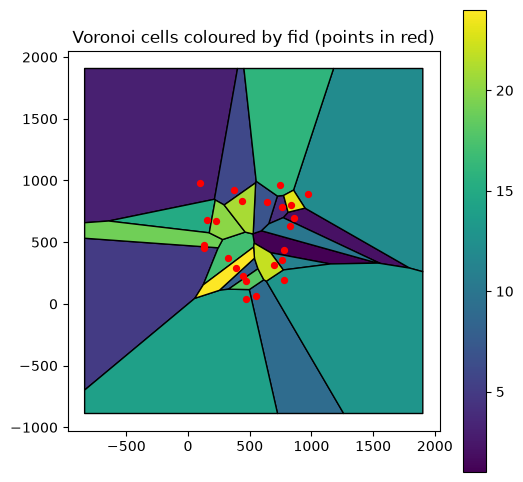

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
gpd.GeoDataFrame(choropleth).plot(
    ax=ax, column='fid', cmap='viridis', edgecolor='black', legend=True
)
gpd.GeoDataFrame(points).plot(ax=ax, color='red', markersize=18)
ax.set_title('Voronoi cells coloured by fid (points in red)')
plt.show()

## Adaptive quad-tree binning

`quadtree()` recursively splits the points' bounding box into quadrants until each cell holds at most
`nmax` points, then attaches a per-cell value. With `column=None` (the default) the value is the **point
count** — a density map.

The `count` column always sums back to the number of binned points.

In [7]:
density = points.quadtree(nmax=2)
print('cells:', len(density), '| columns:', list(density.columns))
print('count sums to point total:', int(density['count'].sum()), '==', len(points))

cells: 15 | columns: ['count', 'geometry']
count sums to point total: 24 == 24


### Aggregate a column per cell — `column=` and `agg=`

Pass a `column` to aggregate it per cell. `agg` accepts the named reducers
`mean`/`sum`/`median`/`min`/`max`/`std`/`count`, or any callable taking a 1-D array.

In [8]:
mean_fid = points.quadtree(column='fid', agg='mean', nmax=3)
print('columns:', list(mean_fid.columns))
mean_fid.head()

columns: ['fid', 'geometry']


,fid,geometry
0,13.0,"POLYGON ((970.698 742.668, 970.698 975.622, 75..."
1,11.5,"POLYGON ((751.568 742.668, 751.568 975.622, 53..."
2,6.0,"POLYGON ((970.698 509.713, 970.698 742.668, 75..."
3,13.5,"POLYGON ((532.438 742.668, 532.438 975.622, 31..."
4,3.0,"POLYGON ((313.308 742.668, 313.308 975.622, 94..."


### `nmax` controls the resolution

A smaller `nmax` forces deeper splitting, so the grid gets finer (more cells). `nmin` drops cells holding
fewer than that many points.

In [9]:
for nmax in (1, 2, 4, 8):
    print(f'nmax={nmax:>2}  ->  {len(points.quadtree(nmax=nmax)):>2} cells')

nmax= 1  ->  21 cells
nmax= 2  ->  15 cells
nmax= 4  ->  13 cells
nmax= 8  ->   4 cells


### Clip the cells and visualise the density grid

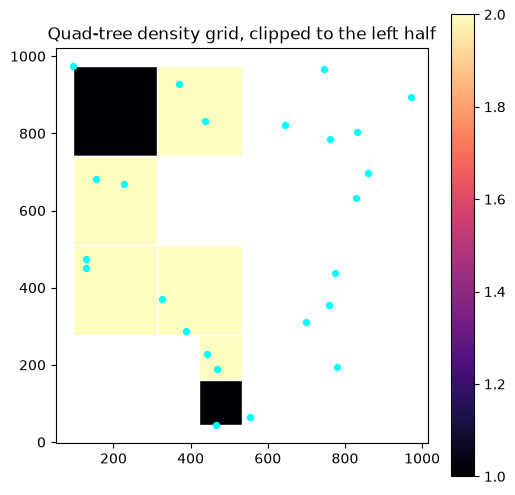

In [10]:
grid = points.quadtree(nmax=2, clip=left_half)

fig, ax = plt.subplots(figsize=(6, 6))
gpd.GeoDataFrame(grid).plot(
    ax=ax, column='count', cmap='magma', edgecolor='white', legend=True
)
gpd.GeoDataFrame(points).plot(ax=ax, color='cyan', markersize=18)
ax.set_title('Quad-tree density grid, clipped to the left half')
plt.show()

## Validation

Both methods are point-only: a non-`Point` geometry raises `InvalidGeometryError`, and an unknown
`agg`, `nmax < 1`, or a missing `column` / `values` raises `ValueError`.

## Summary

- `FeatureCollection.voronoi(values=, clip=)` — Voronoi/Thiessen cells, one per distinct point, optionally
  carrying an attribute and/or clipped to a boundary.
- `FeatureCollection.quadtree(column=, agg=, nmax=, nmin=, clip=)` — adaptive quad-tree binning with a
  per-cell aggregate or point-count density.

Both return polygon `FeatureCollection`s in the input CRS. See the
[Feature subpackage reference](../../reference/feature/index.md) for the full API.